# Walk to Mordor — Two Clocks, One Walker

A personal walking project mapped three virtual Middle-earth journeys onto real-world steps. This notebook examines a central analytical question:

> **How does the same fictional mileage look when read through two different clocks — real-world walking time and Tolkien's Middle-earth chronology?**

A second layer asks: when the fictional journeys are divided into meaningful narrative segments, how does the relationship between the two clocks change across those segments?

---

**Structure**
1. Setup & Data Sources
2. Data Quality Audit
3. Analytical Framework
4. Journey-Level Comparison
5. The Two Clocks
6. Narrative Segments
7. Fictional Travel Rates
8. My Walking Through the Fictional Journey
9. Daily Walking Behaviour
10. Key Findings
11. Limitations & Interpretation

## 1. Setup & Data Sources

In [1]:
import sys, json, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker

warnings.filterwarnings("ignore")

ROOT = Path("__file__").resolve().parent.parent
DATA = ROOT / "docs" / "static" / "data"

# Add notebooks/ to path for wtm_theme
sys.path.insert(0, str(ROOT / "notebooks"))
from wtm_theme import JOURNEY_COLORS, CHARACTER_LABEL, JOURNEY_ORDER, apply_theme

apply_theme()

C = JOURNEY_COLORS    # {'Mordor': '#C17F40', 'Return': '#4A7C8E', 'Hobbit': '#5F8A5A'}
LABEL = CHARACTER_LABEL
JORDER = JOURNEY_ORDER  # ['Mordor', 'Return', 'Hobbit']

print("Packages:", pd.__version__, matplotlib.__version__)
print("Data root:", DATA)

Packages: 3.0.2 3.10.8
Data root: C:\Users\johbr\Data-Analyst\Projects\Walk-to-Mordor\docs\static\data


In [2]:
# ── Load data ──────────────────────────────────────────────────────────────────
walk_all  = pd.read_csv(DATA / "walking.csv", parse_dates=["date"])
me_raw    = pd.read_csv(DATA / "me_time.csv")
chron_raw = json.loads((DATA / "chronology.json").read_text(encoding="utf-8"))
journ_raw = json.loads((DATA / "journeys.json").read_text(encoding="utf-8"))

# Separate journey-assigned walking from gap/unassigned days
walk  = walk_all[walk_all["journey_id"].notna()].copy()
gaps  = walk_all[walk_all["journey_id"].isna()].copy()

# me_time sorted by ordinal within journey
me = me_raw.sort_values(["journey_id", "me_ordinal"]).reset_index(drop=True)

# Chronology — only journey events (drop null journey_id background entries)
chron = pd.DataFrame([e for e in chron_raw if e.get("journey_id") is not None])

# Conqueror journey segments
journ = pd.DataFrame(journ_raw)

print(f"walking.csv: {len(walk_all)} total rows, {len(walk)} journey-assigned, {len(gaps)} gap/unassigned")
print(f"me_time.csv: {len(me)} rows")
print(f"chronology (journey events only): {len(chron)} events")
print(f"journeys.json: {len(journ)} segments")

walking.csv: 806 total rows, 628 journey-assigned, 178 gap/unassigned
me_time.csv: 427 rows
chronology (journey events only): 125 events
journeys.json: 11 segments


## 2. Data Quality Audit

In [3]:
print("=== walking.csv ===")
print(f"Columns: {list(walk_all.columns)}")
print(f"Date range (all rows): {walk_all['date'].min().date()} → {walk_all['date'].max().date()}")
print(f"Duplicate dates: {walk_all.duplicated('date').sum()}")
print(f"Null distance_miles: {walk_all['distance_miles'].isna().sum()} "
      f"(on: {walk_all.loc[walk_all['distance_miles'].isna(), 'date'].dt.date.tolist()})")
print()

for jid in JORDER:
    jw = walk[walk["journey_id"] == jid].sort_values("date")
    cum_diffs = jw["cumulative_miles"].diff().dropna()
    neg = (cum_diffs < -1e-6).sum()
    gaps_in_dates = (jw["date"].diff().dt.days.dropna() > 1).sum()
    max_date_gap = int(jw["date"].diff().dt.days.dropna().max())
    print(f"  {jid}: {len(jw)} rows | "
          f"{jw['date'].min().date()} → {jw['date'].max().date()} | "
          f"total actual mi={jw['distance_miles'].sum():.1f} | "
          f"cum negative diffs={neg} | "
          f"date gaps>1d: {gaps_in_dates} (max {max_date_gap}d)")

print()
print("=== me_time.csv ===")
print(f"Columns: {list(me.columns)}")
non_iso = me[~me["me_date"].str.match(r"^\d{4}-\d{2}-\d{2}$", na=False)]
print(f"Non-ISO dates (intercalary): {len(non_iso)}")
print(non_iso[["journey_id", "me_date", "me_ordinal", "cumulative_miles"]].to_string(index=False))
print()

dup_ords = me[me.duplicated("me_ordinal", keep=False)]
print(f"Duplicate me_ordinals: {len(dup_ords)} rows across {dup_ords['me_ordinal'].nunique()} ordinals")
print("  → These are ordinals shared by Mordor and Return (simultaneous journeys, Mar 3019).")
print(f"  → Shared ordinal range: {dup_ords['me_ordinal'].min()} – {dup_ords['me_ordinal'].max()}")
print()

for jid in JORDER:
    jme = me[me["journey_id"] == jid]
    cum_neg = (jme["cumulative_miles"].diff().dropna() < -1e-6).sum()
    print(f"  {jid}: {len(jme)} rows | "
          f"ordinals {jme['me_ordinal'].min()}–{jme['me_ordinal'].max()} | "
          f"max cum mi={jme['cumulative_miles'].max():.1f} | "
          f"cum negative diffs={cum_neg}")

=== walking.csv ===
Columns: ['date', 'journey_id', 'character', 'segment', 'distance_miles', 'cumulative_miles', 'all_time_cumulative_miles']
Date range (all rows): 2024-03-27 → 2026-06-10
Duplicate dates: 0
Null distance_miles: 1 (on: [datetime.date(2025, 12, 9)])

  Mordor: 261 rows | 2024-03-27 → 2025-01-07 | total actual mi=1823.0 | cum negative diffs=0 | date gaps>1d: 1 (max 27d)
  Return: 225 rows | 2025-01-14 → 2025-08-26 | total actual mi=1493.5 | cum negative diffs=0 | date gaps>1d: 0 (max 1d)
  Hobbit: 142 rows | 2026-01-20 → 2026-06-10 | total actual mi=1148.1 | cum negative diffs=0 | date gaps>1d: 0 (max 1d)

=== me_time.csv ===
Columns: ['me_year', 'me_date', 'me_ordinal', 'journey_id', 'cumulative_miles']
Non-ISO dates (intercalary): 5
journey_id       me_date  me_ordinal  cumulative_miles
    Hobbit       1 Lithe         181             491.0
    Hobbit Midyear's Day         182             491.0
    Hobbit       2 Lithe         183             494.4
    Mordor        Y

**Audit notes:**
- One null `distance_miles` row in the gap period (2025-12-09). Not assigned to any journey; excluded from journey analysis.
- 178 gap rows carry real walking data but no fictional journey assignment. They are included in the all-time cumulative but excluded from per-journey analysis.
- Duplicate `me_ordinal` values (30 ordinals × 2 journeys = 60 rows) are **expected**: Frodo and Aragorn travel simultaneously in TA 3019 February–March. This is not a data error.
- Five intercalary Shire calendar dates appear in `me_time.csv`. All have valid ordinals and are treated as ordinary days in duration arithmetic.
- One one-day flat in Mordor me_time (ord 28557, 3019-03-08, mi=1567): likely a rest at Henneth Annûn. Not large enough to define as a separate segment.
- Cumulative mileage is monotonically non-decreasing in all three journeys in both datasets.

## 3. Analytical Framework

### Two temporal systems

| Dimension | My Time | Middle-earth Time |
|-----------|---------|-------------------|
| Calendar | Real-world dates (2024–2026) | Tolkien Shire calendar ordinals |
| Unit | Actual miles walked (Google Fit) | Calibrated fictional journey miles |
| Source | `walking.csv` | `me_time.csv` |
| Progress measure | `cumulative_miles` (actual) | `cumulative_miles` (fictional) |

The two systems cover approximately the same total mileage per journey (actual ≈ fictional), because The Conqueror app calibrates fictional progress from actual walking. However, the **time** and **shape** of that progress differ.

### Variable types

| Type | Examples |
|------|----------|
| **Measured** | actual miles, walking date, ME ordinal, fictional miles, challenge assignment |
| **Derived** | walking rate, fictional travel rate, elapsed days, segment duration, streaks |
| **Narrative annotation** | travel mode (walking / horseback / boat / rest / captivity), location, event |

Travel mode annotations are derived from `chronology.json` and Tolkien source narrative, not from statistical discovery. They are interpretations, not measurements. The user always walked — fictional travel mode describes the characters' situation, not the user's.

### Segment methodology

Segments are defined by **ordinal boundaries** in `me_time.csv`, not by inclusive mileage ranges. The boundary convention used throughout is:

> A segment spans ordinals `[start_ord, end_ord]` inclusive. The segment's start mileage is the cumulative miles at `start_ord`; end mileage is the cumulative miles at `end_ord`.

For movement segments the start mileage of segment N equals the end mileage of segment N−1. For rest/captivity segments the start and end mileage are equal (flat plateau).

## 4. Journey-Level Comparison

In [4]:
rows = []
for jid in JORDER:
    jw  = walk[walk["journey_id"] == jid].sort_values("date")
    jme = me[me["journey_id"] == jid].sort_values("me_ordinal")

    # My Time
    w_elapsed  = (jw["date"].max() - jw["date"].min()).days + 1
    w_days     = len(jw)
    w_total_mi = jw["distance_miles"].sum()
    w_mean     = jw["distance_miles"].mean()
    w_med      = jw["distance_miles"].median()
    w_std      = jw["distance_miles"].std()

    # ME Time
    me_elapsed     = jme["me_ordinal"].max() - jme["me_ordinal"].min() + 1
    me_fi_miles    = jme["cumulative_miles"].max()    # final fictional mile
    me_travel_days = (jme["cumulative_miles"].diff() > 0).sum()
    me_rest_days   = me_elapsed - me_travel_days

    rows.append(dict(
        journey=jid,
        character=LABEL[jid],
        w_start=jw["date"].min().date(), w_end=jw["date"].max().date(),
        w_elapsed=w_elapsed, w_days=w_days,
        w_total_mi=round(w_total_mi, 1),
        w_mean=round(w_mean, 2), w_med=round(w_med, 2), w_std=round(w_std, 2),
        me_elapsed=int(me_elapsed), me_fi_miles=int(me_fi_miles),
        me_travel_days=int(me_travel_days), me_rest_days=int(me_rest_days),
        me_avg_rate=round(me_fi_miles / me_elapsed, 2),
        time_ratio=round(w_elapsed / me_elapsed, 2),
    ))

js = pd.DataFrame(rows)

# Display My Time summary
display_cols = ["character","w_start","w_end","w_elapsed","w_days",
                "w_total_mi","w_mean","w_med","w_std"]
print("MY TIME — walking data")
display(js[display_cols].rename(columns={
    "character":"Journey","w_start":"Start","w_end":"End",
    "w_elapsed":"Calendar days","w_days":"Walking days",
    "w_total_mi":"Total mi","w_mean":"Mean mi/day",
    "w_med":"Median mi/day","w_std":"Std dev"}))

print()
me_cols = ["character","me_elapsed","me_fi_miles",
           "me_travel_days","me_rest_days","me_avg_rate"]
print("MIDDLE-EARTH TIME")
display(js[me_cols].rename(columns={
    "character":"Journey","me_elapsed":"ME days",
    "me_fi_miles":"Fictional mi","me_travel_days":"Travel days",
    "me_rest_days":"Rest/flat days","me_avg_rate":"Avg fi-mi/ME-day"}))

print()
ratio_cols = ["character","w_elapsed","me_elapsed","time_ratio","w_total_mi","me_fi_miles"]
print("TWO-CLOCK COMPARISON")
print("  time_ratio = real-world elapsed calendar days / ME elapsed days")
display(js[ratio_cols].rename(columns={
    "character":"Journey","w_elapsed":"Real days","me_elapsed":"ME days",
    "time_ratio":"Real/ME ratio","w_total_mi":"Actual mi","me_fi_miles":"Fictional mi"}))

MY TIME — walking data


,Journey,Start,End,Calendar days,Walking days,Total mi,Mean mi/day,Median mi/day,Std dev
0,Frodo — Mordor,2024-03-27,2025-01-07,287,261,1823.0,6.98,7.12,3.37
1,Aragorn — Return of the King,2025-01-14,2025-08-26,225,225,1493.5,6.64,6.49,2.93
2,Bilbo — The Hobbit,2026-01-20,2026-06-10,142,142,1148.1,8.09,7.93,3.09



MIDDLE-EARTH TIME


,Journey,ME days,Fictional mi,Travel days,Rest/flat days,Avg fi-mi/ME-day
0,Frodo — Mordor,185,1815,90,95,9.81
1,Aragorn — Return of the King,30,1482,25,5,49.40
2,Bilbo — The Hobbit,212,1100,121,91,5.19



TWO-CLOCK COMPARISON
  time_ratio = real-world elapsed calendar days / ME elapsed days


,Journey,Real days,ME days,Real/ME ratio,Actual mi,Fictional mi
0,Frodo — Mordor,287,185,1.55,1823.0,1815
1,Aragorn — Return of the King,225,30,7.50,1493.5,1482
2,Bilbo — The Hobbit,142,212,0.67,1148.1,1100


## 5. The Two Clocks

For each journey, the same fictional mileage is covered by two calendars. The figure below plots cumulative fictional miles against elapsed days for both timelines.

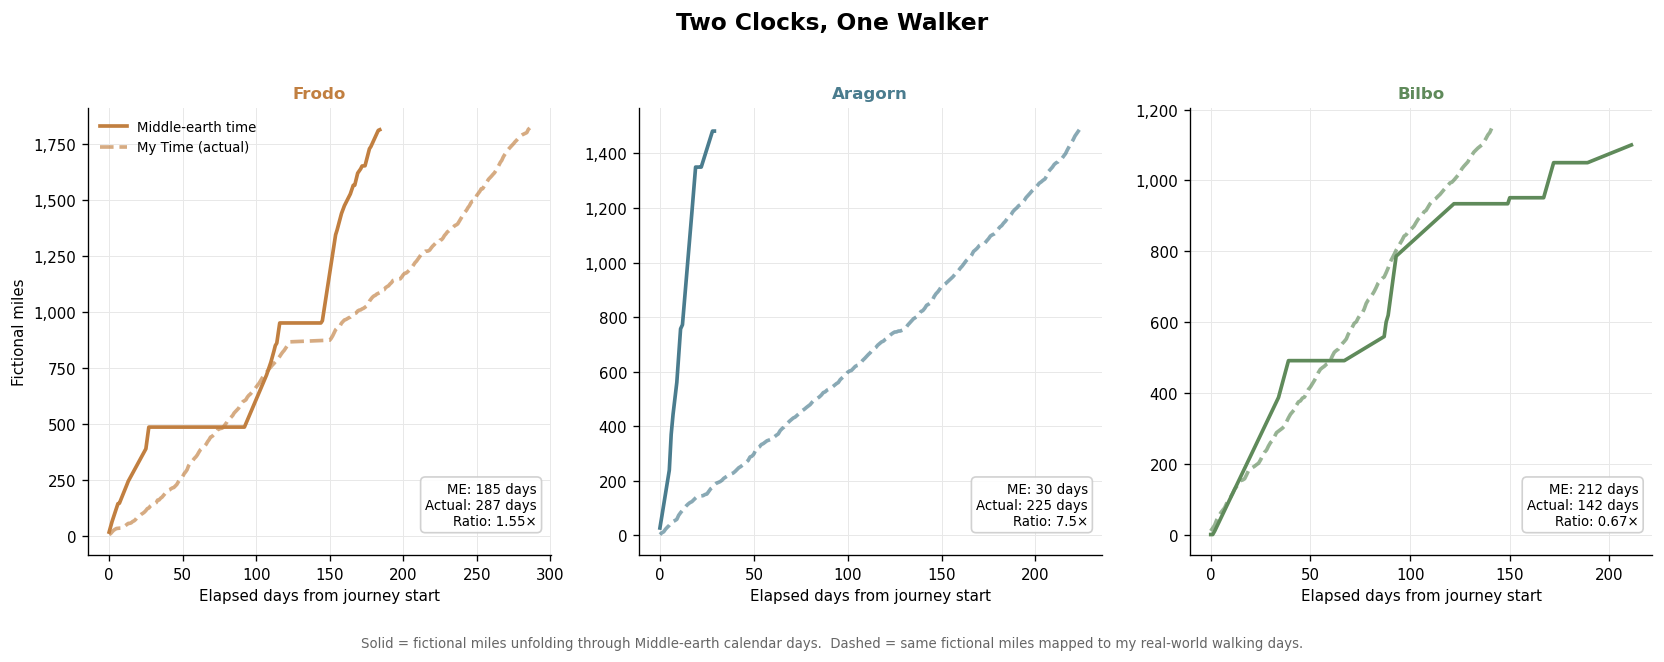

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle("Two Clocks, One Walker",
             fontsize=14, fontweight="bold", y=1.02)

for ax, jid in zip(axes, JORDER):
    color = C[jid]
    jw  = walk[walk["journey_id"] == jid].sort_values("date").copy()
    jme = me[me["journey_id"] == jid].sort_values("me_ordinal").copy()

    # ME time: ordinal index from 0
    jme["day_idx"] = jme["me_ordinal"] - jme["me_ordinal"].min()

    # My Time: calendar day index from 0
    jw["day_idx"] = (jw["date"] - jw["date"].min()).dt.days

    row = js[js["journey"] == jid].iloc[0]

    ax.plot(jme["day_idx"], jme["cumulative_miles"],
            color=color, linewidth=2.2, label="Middle-earth time", zorder=3)
    ax.plot(jw["day_idx"], jw["cumulative_miles"],
            color=color, linewidth=2.2, linestyle="--", alpha=0.65,
            label="My Time (actual)", zorder=3)

    ax.set_title(LABEL[jid].split("—")[0].strip(),
                 fontsize=10, fontweight="bold", color=color)
    ax.set_xlabel("Elapsed days from journey start", fontsize=9)
    if ax == axes[0]:
        ax.set_ylabel("Fictional miles", fontsize=9)

    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))

    # Annotation
    ax.text(0.97, 0.06,
            f"ME: {row.me_elapsed} days\nActual: {row.w_elapsed} days\nRatio: {row.time_ratio}×",
            transform=ax.transAxes, ha="right", va="bottom", fontsize=8,
            bbox=dict(boxstyle="round,pad=0.35", fc="white", ec="#CCCCCC", alpha=0.9))

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

axes[0].legend(fontsize=8, loc="upper left")

fig.text(0.5, -0.04,
         "Solid = fictional miles unfolding through Middle-earth calendar days.  "
         "Dashed = same fictional miles mapped to my real-world walking days.",
         ha="center", fontsize=8, color="#666666")

fig.tight_layout()
plt.show()

**Reading the Two Clocks figure.** Both lines for each journey start at (0, 0) and end at approximately the same total mileage. What differs is the shape:

- **Frodo (Mordor):** The solid ME line has long horizontal stretches (Rivendell rest, Lothlórien rest) where no fictional miles accumulate for weeks. The dashed real-world line is smoother — I kept walking. Real calendar elapsed time (287 days) is about 1.55× the ME elapsed time (185 days).

- **Aragorn (Return):** The ME line is nearly vertical — 1,482 fictional miles in just 30 ME days. My real-world line stretches across 225 calendar days (7.5× the ME duration), creating an enormous divergence between the two clocks. The fiction moves far faster than I could.

- **Bilbo (Hobbit):** The ME line has multiple flat stretches (Rivendell rest, Wood-elves captivity, Lake-town rest), but the ME total (212 days) is *longer* than my real-world journey (142 calendar days). The ratio is 0.67× — my walking was actually faster than Tolkien's fictional timeline. Bilbo's story unfolds slowly; I finished it before it ended.

## 6. Narrative Segments

Segments are defined by `me_ordinal` boundaries drawn from `me_time.csv` plateau analysis and `chronology.json` anchors.

**Boundary convention:** A segment owns ordinals `[start_ord, end_ord]` inclusive. Adjacent segments share a mileage value at their junction but no ordinals overlap.

In [6]:
# ── Segment definitions by ordinal ─────────────────────────────────────────────
# Each entry: (name, start_ord, end_ord, travel_mode, mode_basis)
# travel_mode is a narrative annotation from chronology, not a measured variable.

SEG_DEFS = {
    "Mordor": [
        # ords 28390-28417: Shire depart → Ford of Bruinen → Rivendell arrival
        ("Bag End → Rivendell",             28390, 28417, "walking",   "chronology"),
        # ords 28418-28482: flat at 487 mi (3018-10-21 to 3018-12-25)
        ("Rivendell Rest",                  28418, 28482, "rest",      "chronology"),
        # ords 28483-28506: depart Rivendell → arrive Lothlórien (incl. Moria)
        ("Rivendell → Lothlórien",   28483, 28506, "walking",   "chronology"),
        # ords 28507-28534: flat at 952 mi (3019-01-18 to 3019-02-15)
        ("Lothlórien Rest",                 28507, 28534, "rest",      "chronology"),
        # ords 28535-28545: depart Silverlode → Parth Galen (boats on Anduin)
        ("Boats on the Anduin",             28535, 28545, "boat",      "chronology"),
        # ords 28546-28561: Emyn Muil → Shelob's Lair (walking)
        ("Parth Galen → Shelob's Lair",     28546, 28561, "walking",   "chronology"),
        # ords 28562-28574: Cirith Ungol escape → Cracks of Doom
        ("Cirith Ungol → Cracks of Doom",   28562, 28574, "walking",   "chronology"),
    ],
    "Return": [
        # ords 28545-28551: Parth Galen → Edoras (horseback, ~42 fi-mi/day)
        ("Parth Galen → Edoras",            28545, 28551, "horseback", "chronology"),
        # ords 28552-28556: Edoras → Dunharrow (~77 fi-mi/day)
        ("Edoras → Dunharrow",              28552, 28556, "horseback", "chronology"),
        # ords 28557-28564: Paths of Dead → Pelargir → Minas Tirith (mixed)
        ("Dunharrow → Minas Tirith",        28557, 28564, "mixed",     "chronology"),
        # ords 28565-28567: flat at 1350 mi (3019-03-16 to 3019-03-18)
        ("Minas Tirith Rest",               28565, 28567, "rest",      "chronology"),
        # ords 28568-28574: march to Black Gate + final battle
        ("Minas Tirith → Black Gate",       28568, 28574, "walking",   "chronology"),
    ],
    "Hobbit": [
        # ords 115-154: Bag End → Rivendell (walking; ponies available but travel is slow)
        ("Bag End → Rivendell",             115,   154,   "walking",   "chronology"),
        # ords 155-182: flat at 491 mi (2941-06-05 to Midyear's Day)
        ("Rivendell Rest",                  155,   182,   "rest",      "chronology"),
        # ords 183-204: depart → High Pass → Goblin-town → Eagle rescue → Beorn's Hall
        ("Rivendell → Beorn's Hall",        183,   204,   "mixed",     "chronology"),
        # ords 205-208: Beorn → Mirkwood entrance on ponies (~42 fi-mi/day)
        ("Beorn → Mirkwood Entrance",       205,   208,   "horseback", "chronology"),
        # ords 209-237: walking through Mirkwood
        ("Through Mirkwood",                209,   237,   "walking",   "chronology"),
        # ords 238-264: flat at 934 mi (captivity in Elvenking's Halls)
        ("Wood-elves Captivity",            238,   264,   "captivity", "chronology"),
        # ord 265 only: barrel escape to Esgaroth (1 ME day, 17 fi-mi)
        ("Barrel Escape → Esgaroth",        265,   265,   "boat",      "chronology"),
        # ords 266-282: flat at 951 mi (Lake-town rest)
        ("Lake-town Rest",                  266,   282,   "rest",      "chronology"),
        # ords 283-326: Esgaroth → Lonely Mountain → Battle of Five Armies
        ("Esgaroth → Lonely Mountain",      283,   326,   "mixed",     "chronology"),
    ],
}

print("Segment definitions loaded. Verifying ordinal coverage...")
for jid in JORDER:
    jme = me[me["journey_id"] == jid]
    total_me_rows = len(jme)
    segs = SEG_DEFS[jid]
    covered = sum(e - s + 1 for _, s, e, *_ in segs)
    print(f"  {jid}: {len(segs)} segments, {covered} ordinals covered, {total_me_rows} total ME rows "
          f"{'✓' if covered == total_me_rows else f'⚠ MISMATCH ({covered} vs {total_me_rows})'}")

Segment definitions loaded. Verifying ordinal coverage...
  Mordor: 7 segments, 185 ordinals covered, 185 total ME rows ✓
  Return: 5 segments, 30 ordinals covered, 30 total ME rows ✓
  Hobbit: 9 segments, 212 ordinals covered, 212 total ME rows ✓


In [7]:

# ── Compute segment statistics ──────────────────────────────────────────────────
# fi_mi = mi[end_ord] - mi[prev_end_ord]
# This avoids taking the first row's intra-day accumulated mileage as the start.

def compute_segs(jid, seg_defs, me_df, walk_df):
    jme = me_df[me_df["journey_id"] == jid].sort_values("me_ordinal").set_index("me_ordinal")
    jw  = walk_df[walk_df["journey_id"] == jid].sort_values("date")

    records = []
    prev_end_mi = 0.0  # journey starts at 0 fictional miles

    for i, (name, s_ord, e_ord, travel, mode_basis) in enumerate(seg_defs):
        seg_me = jme.loc[s_ord:e_ord]  # inclusive both ends

        me_days    = len(seg_me)
        fi_mi_start = prev_end_mi
        fi_mi_end   = float(seg_me["cumulative_miles"].iloc[-1]) if me_days > 0 else fi_mi_start
        fi_mi       = fi_mi_end - fi_mi_start
        fi_rate     = round(fi_mi / me_days, 2) if (me_days > 0 and fi_mi > 0) else 0.0

        # Map actual walking days to this fictional mileage interval.
        # For rest/captivity (fi_mi == 0): no walking days cross this zero-width interval.
        if fi_mi > 0:
            mask_w = (jw["cumulative_miles"] > fi_mi_start) & (jw["cumulative_miles"] <= fi_mi_end)
            seg_w  = jw[mask_w]
        else:
            seg_w = jw.iloc[0:0]

        w_actual_mi = round(float(seg_w["distance_miles"].sum()), 1)
        w_days      = len(seg_w)
        w_elapsed   = (
            int((seg_w["date"].max() - seg_w["date"].min()).days) + 1
            if w_days > 1 else (1 if w_days == 1 else 0)
        )
        w_rate = round(w_actual_mi / w_days, 2) if w_days > 0 else 0.0

        records.append(dict(
            journey=jid, segment=name, travel=travel, mode_basis=mode_basis,
            start_ord=s_ord, end_ord=e_ord,
            fi_mi_start=round(fi_mi_start, 1),
            fi_mi_end=round(fi_mi_end, 1),
            fi_mi=round(fi_mi, 1), me_days=me_days, fi_rate=fi_rate,
            w_actual_mi=w_actual_mi, w_days=w_days,
            w_elapsed=w_elapsed, w_rate=w_rate,
        ))
        prev_end_mi = fi_mi_end  # carry forward for next segment

    return records

all_records = []
for jid in JORDER:
    all_records.extend(compute_segs(jid, SEG_DEFS[jid], me, walk))

segs = pd.DataFrame(all_records)

# Display segment tables
for jid in JORDER:
    print(f"\n{'─'*70}")
    print(f"  {LABEL[jid]}")
    print(f"{'─'*70}")
    cols = ["segment","travel","me_days","fi_mi","fi_rate",
            "w_days","w_actual_mi","w_rate"]
    hdrs = {"segment":"Segment","travel":"Mode","me_days":"ME days",
            "fi_mi":"Fict mi","fi_rate":"fi-mi/ME-day",
            "w_days":"Walk days","w_actual_mi":"Actual mi","w_rate":"mi/walk-day"}
    display(segs[segs["journey"]==jid][cols].rename(columns=hdrs).reset_index(drop=True))

# Verify totals
print("\nSegment totals vs journey totals:")
for jid in JORDER:
    row = js[js["journey"]==jid].iloc[0]
    jseg = segs[segs["journey"]==jid]
    me_days_sum = jseg["me_days"].sum()
    fi_mi_sum   = jseg["fi_mi"].sum()
    print(f"  {jid}: ME days {me_days_sum} vs {row.me_elapsed} "
          f"{'✓' if me_days_sum == row.me_elapsed else '⚠'} | "
          f"fi-mi {fi_mi_sum:.0f} vs {row.me_fi_miles} "
          f"{'✓' if abs(fi_mi_sum - row.me_fi_miles) < 1 else '⚠'}")



──────────────────────────────────────────────────────────────────────
  Frodo — Mordor
──────────────────────────────────────────────────────────────────────


,Segment,Mode,ME days,Fict mi,fi-mi/ME-day,Walk days,Actual mi,mi/walk-day
0,Bag End → Rivendell,walking,28,487.0,17.39,78,482.7,6.19
1,Rivendell Rest,rest,65,0.0,0.00,0,0.0,0.00
2,Rivendell → Lothlórien,walking,24,465.0,19.38,55,468.5,8.52
3,Lothlórien Rest,rest,28,0.0,0.00,0,0.0,0.00
4,Boats on the Anduin,boat,11,415.0,37.73,73,412.3,5.65
5,Parth Galen → Shelob's Lair,walking,16,273.0,17.06,32,269.5,8.42
6,Cirith Ungol → Cracks of Doom,walking,13,175.0,13.46,21,169.2,8.06



──────────────────────────────────────────────────────────────────────
  Aragorn — Return of the King
──────────────────────────────────────────────────────────────────────


,Segment,Mode,ME days,Fict mi,fi-mi/ME-day,Walk days,Actual mi,mi/walk-day
0,Parth Galen → Edoras,horseback,7,370.0,52.86,63,367.0,5.83
1,Edoras → Dunharrow,horseback,5,387.0,77.40,68,387.5,5.70
2,Dunharrow → Minas Tirith,mixed,8,593.0,74.12,79,595.3,7.54
3,Minas Tirith Rest,rest,3,0.0,0.00,0,0.0,0.00
4,Minas Tirith → Black Gate,walking,7,132.0,18.86,13,123.8,9.52



──────────────────────────────────────────────────────────────────────
  Bilbo — The Hobbit
──────────────────────────────────────────────────────────────────────


,Segment,Mode,ME days,Fict mi,fi-mi/ME-day,Walk days,Actual mi,mi/walk-day
0,Bag End → Rivendell,walking,40,491.0,12.28,60,483.8,8.06
1,Rivendell Rest,rest,28,0.0,0.00,0,0.0,0.00
2,Rivendell → Beorn's Hall,mixed,22,128.0,5.82,15,127.9,8.53
3,Beorn → Mirkwood Entrance,horseback,4,167.0,41.75,17,168.0,9.88
4,Through Mirkwood,walking,29,148.0,5.10,19,154.1,8.11
5,Wood-elves Captivity,captivity,27,0.0,0.00,0,0.0,0.00
6,Barrel Escape → Esgaroth,boat,1,17.0,17.00,3,15.4,5.13
7,Lake-town Rest,rest,17,0.0,0.00,0,0.0,0.00
8,Esgaroth → Lonely Mountain,mixed,44,149.0,3.39,22,146.5,6.66



Segment totals vs journey totals:
  Mordor: ME days 185 vs 185 ✓ | fi-mi 1815 vs 1815 ✓
  Return: ME days 30 vs 30 ✓ | fi-mi 1482 vs 1482 ✓
  Hobbit: ME days 212 vs 212 ✓ | fi-mi 1100 vs 1100 ✓


**Segment notes:**

- **Rivendell rest (Mordor):** ordinals 28418–28482, 65 ME days. The largest single stationary phase in the dataset. The flat starts on ordinal 28418 (3018-10-21), four days before the chronology's canonical Rivendell arrival (3018-10-24), reflecting the mileage calibration placing arrival slightly earlier in `me_time`.
- **Lothlórien rest (Mordor):** ordinals 28507–28534, 28 ME days. Begins the day after the fellowship arrives at mi=952. The preceding segment (
) covers the full travel from Rivendell departure to that arrival, including Moria.
- **Boats on the Anduin:** ordinals 28535–28545, 11 ME days. Begins the day movement resumes from Lothlórien (mi=962, not 952) — the first 10 mi represent the Silverlode paddle to the Hythe.
- **Barrel escape (Bilbo):** ordinal 265 only, 1 ME day, 17 fictional miles. The subsequent Lake-town rest (ordinals 266–282) is cleanly separated on its own ordinal range.
- **Wood-elves captivity (Bilbo):** 27 ME days flat at 934 mi. No real-world walking days are mapped here since my cumulative mileage crossed 934 during normal travel.
- **Return journey:** all 30 ME days, no segment totals lost. Minas Tirith rest (3 days) is explicitly separated from the final march.

## 7. Fictional Travel Rates

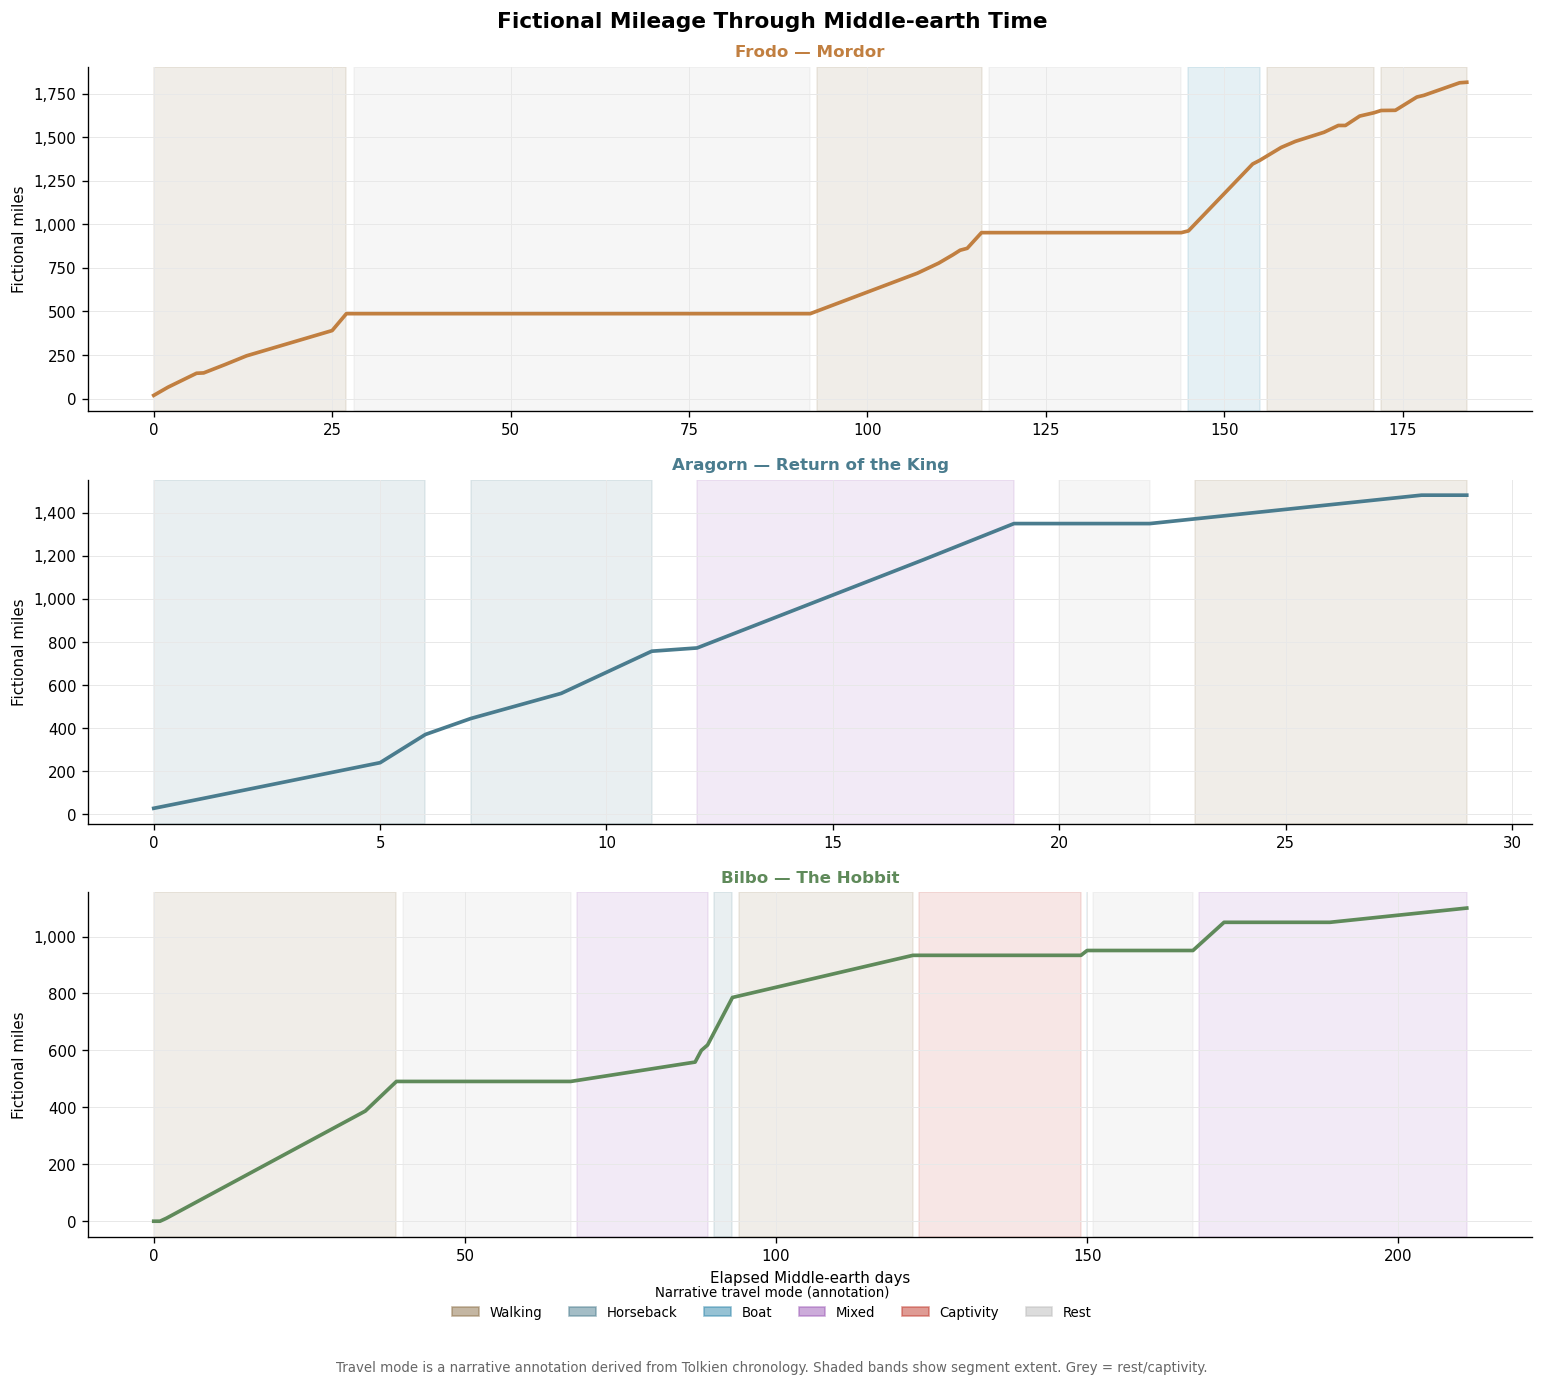

In [8]:
# ── Fictional narrative mileage: cumulative fi-miles vs ME ordinal ─────────────
TRAVEL_PALETTE = {
    "walking":   "#8B6F47",
    "horseback": "#4A7C8E",
    "boat":      "#2E86AB",
    "mixed":     "#9B59B6",
    "captivity": "#C0392B",
    "rest":      "#BBBBBB",
}

fig, axes = plt.subplots(3, 1, figsize=(13, 11))
fig.suptitle("Fictional Mileage Through Middle-earth Time",
             fontsize=13, fontweight="bold")

for ax, jid in zip(axes, JORDER):
    color = C[jid]
    jme = me[me["journey_id"] == jid].sort_values("me_ordinal").copy()
    jme["ord_idx"] = jme["me_ordinal"] - jme["me_ordinal"].min()

    # Shade segments by travel mode
    for _, row in segs[segs["journey"] == jid].iterrows():
        s_idx = row.start_ord - jme["me_ordinal"].min()
        e_idx = row.end_ord   - jme["me_ordinal"].min()
        shade = TRAVEL_PALETTE.get(row.travel, "#EEEEEE")
        ax.axvspan(s_idx, e_idx, alpha=0.12, color=shade, zorder=1)

    ax.plot(jme["ord_idx"], jme["cumulative_miles"],
            color=color, linewidth=2.2, zorder=3)

    ax.set_title(LABEL[jid], fontsize=10, fontweight="bold", color=color)
    ax.set_ylabel("Fictional miles", fontsize=9)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

axes[-1].set_xlabel("Elapsed Middle-earth days", fontsize=9)

# Shared legend
mode_handles = [
    mpatches.Patch(color=TRAVEL_PALETTE[m], alpha=0.5, label=m.capitalize())
    for m in ["walking", "horseback", "boat", "mixed", "captivity", "rest"]
]
fig.legend(handles=mode_handles, title="Narrative travel mode (annotation)",
           title_fontsize=8, fontsize=8, loc="lower center",
           ncol=6, bbox_to_anchor=(0.5, -0.02), frameon=False)

fig.text(0.5, -0.05,
         "Travel mode is a narrative annotation derived from Tolkien chronology. "
         "Shaded bands show segment extent. Grey = rest/captivity.",
         ha="center", fontsize=8, color="#666666")
fig.tight_layout()
plt.show()

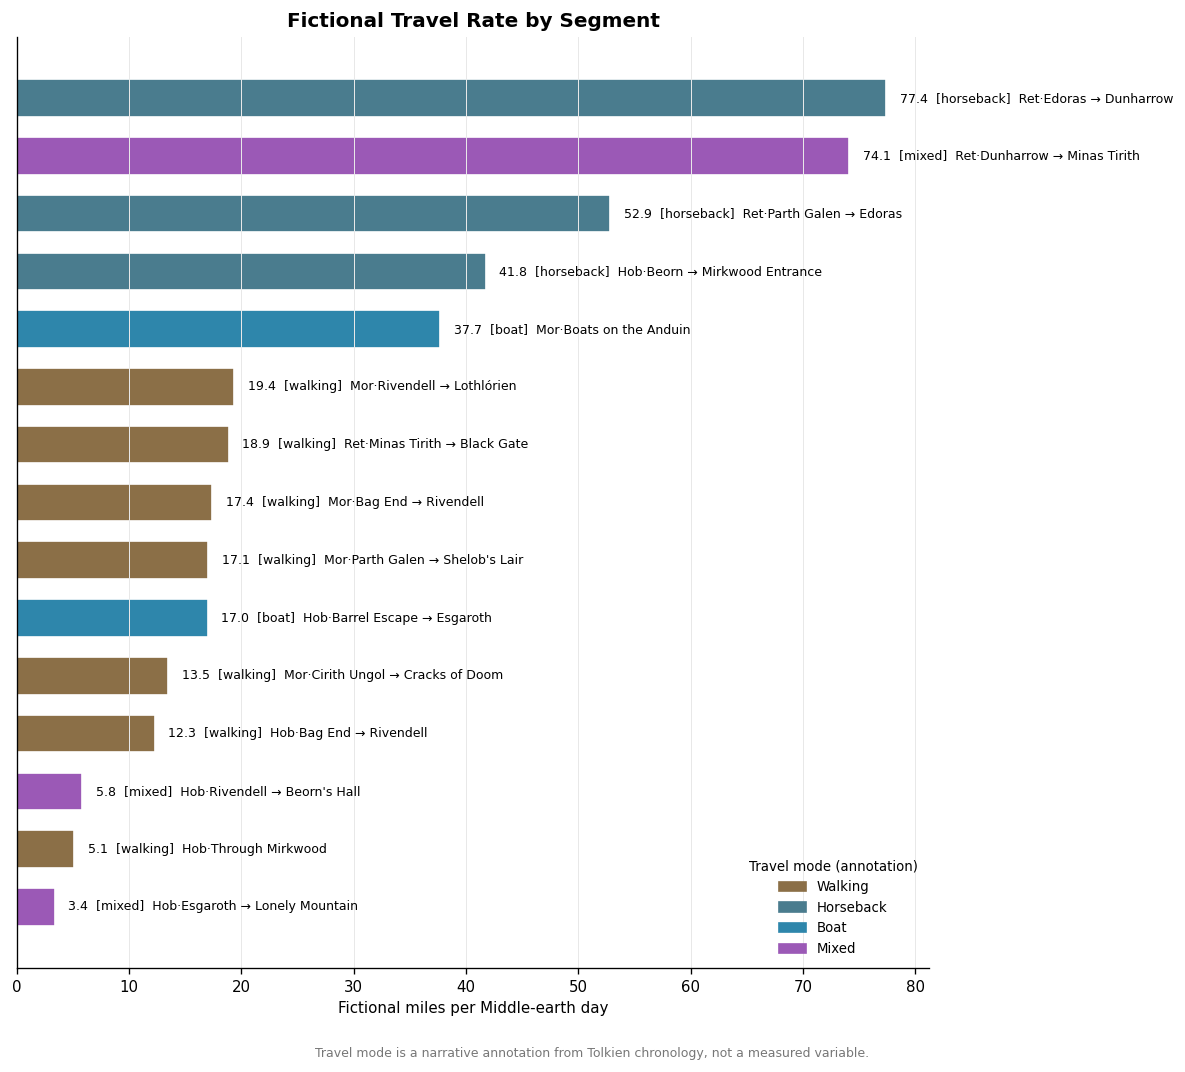

In [9]:
# ── Fictional travel rate by segment (movement segments only) ──────────────────
move_segs = segs[segs["fi_mi"] > 0].copy()
move_segs = move_segs.sort_values("fi_rate", ascending=False)

fig, ax = plt.subplots(figsize=(10, max(5, len(move_segs) * 0.48 + 1.5)))
ax.set_title("Fictional Travel Rate by Segment",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Fictional miles per Middle-earth day", fontsize=9)

ys = np.arange(len(move_segs))
bar_colors = [TRAVEL_PALETTE.get(r["travel"], "#AAAAAA")
              for _, r in move_segs.iterrows()]

bars = ax.barh(ys, move_segs["fi_rate"].values,
               color=bar_colors, height=0.65, edgecolor="white")

for y, row in zip(ys, move_segs.itertuples()):
    label = f"  {row.fi_rate:.1f}  [{row.travel}]  {row.journey[:3]}·{row.segment}"
    ax.text(row.fi_rate + 0.5, y, label, va="center", fontsize=7.5)

ax.set_yticks([])
ax.invert_yaxis()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

mode_handles = [
    mpatches.Patch(color=TRAVEL_PALETTE[m], label=m.capitalize())
    for m in ["walking", "horseback", "boat", "mixed", "captivity"]
    if m in move_segs["travel"].values
]
ax.legend(handles=mode_handles, title="Travel mode (annotation)",
          title_fontsize=8, fontsize=8, loc="lower right")

fig.text(0.5, -0.02,
         "Travel mode is a narrative annotation from Tolkien chronology, not a measured variable.",
         ha="center", fontsize=7.5, color="#777777")
fig.tight_layout()
plt.show()

**Fictional travel rate observations.** The range across segments is large. Horseback segments in the Return journey reach the highest rates in the dataset (52–77 fi-mi/day), consistent with the narrative annotation of mounted movement. The boat segment on the Anduin (37.7 fi-mi/day) is substantially faster than any of Frodo's walking segments. Bilbo's pony leg (Beorn → Mirkwood, ~42 fi-mi/day) shows a similar boost relative to walking pace. Walking segments cluster between roughly 2.5 and 21 fi-mi/day, with the Bag End → Bree leg being the highest-rate walking segment.

## 8. My Walking Through the Fictional Journey

For each movement segment, actual walking days are those where `cumulative_miles` in `walking.csv` crossed from the segment's start mileage to its end mileage. Rest/captivity segments (fictional miles = 0) have no corresponding real-world rest — I kept walking through those mileage points continuously.

In [10]:
# ── Summary table: fictional vs actual for movement segments ───────────────────
move = segs[segs["fi_mi"] > 0].copy()

# Add rest context: note each rest segment and what it means in my time
rest_segs = segs[segs["fi_mi"] == 0].copy()
print("Rest/captivity segments (fictional days with no mileage progress):")
print("In My Time, these segments have no equivalent — I walked through those mileage")
print("points without pause.\n")
display(rest_segs[["journey","segment","travel","me_days","fi_mi_start"]].rename(columns={
    "journey":"Journey","segment":"Segment","travel":"Type",
    "me_days":"ME days","fi_mi_start":"Mileage mark"}).reset_index(drop=True))

print()
print("Movement segments — fictional vs actual walking:")
cols = ["journey","segment","travel","fi_mi","me_days","fi_rate",
        "w_days","w_actual_mi","w_rate"]
hdrs = {"journey":"Journey","segment":"Segment","travel":"Mode",
        "fi_mi":"Fict mi","me_days":"ME days","fi_rate":"fi-mi/ME-day",
        "w_days":"Walk days","w_actual_mi":"Actual mi","w_rate":"mi/walk-day"}
display(move[cols].rename(columns=hdrs).reset_index(drop=True))

Rest/captivity segments (fictional days with no mileage progress):
In My Time, these segments have no equivalent — I walked through those mileage
points without pause.



,Journey,Segment,Type,ME days,Mileage mark
0,Mordor,Rivendell Rest,rest,65,487.0
1,Mordor,Lothlórien Rest,rest,28,952.0
2,Return,Minas Tirith Rest,rest,3,1350.0
3,Hobbit,Rivendell Rest,rest,28,491.0
4,Hobbit,Wood-elves Captivity,captivity,27,934.0
5,Hobbit,Lake-town Rest,rest,17,951.0



Movement segments — fictional vs actual walking:


,Journey,Segment,Mode,Fict mi,ME days,fi-mi/ME-day,Walk days,Actual mi,mi/walk-day
0,Mordor,Bag End → Rivendell,walking,487.0,28,17.39,78,482.7,6.19
1,Mordor,Rivendell → Lothlórien,walking,465.0,24,19.38,55,468.5,8.52
2,Mordor,Boats on the Anduin,boat,415.0,11,37.73,73,412.3,5.65
3,Mordor,Parth Galen → Shelob's Lair,walking,273.0,16,17.06,32,269.5,8.42
4,Mordor,Cirith Ungol → Cracks of Doom,walking,175.0,13,13.46,21,169.2,8.06
5,Return,Parth Galen → Edoras,horseback,370.0,7,52.86,63,367.0,5.83
6,Return,Edoras → Dunharrow,horseback,387.0,5,77.40,68,387.5,5.70
7,Return,Dunharrow → Minas Tirith,mixed,593.0,8,74.12,79,595.3,7.54
8,Return,Minas Tirith → Black Gate,walking,132.0,7,18.86,13,123.8,9.52
9,Hobbit,Bag End → Rivendell,walking,491.0,40,12.28,60,483.8,8.06


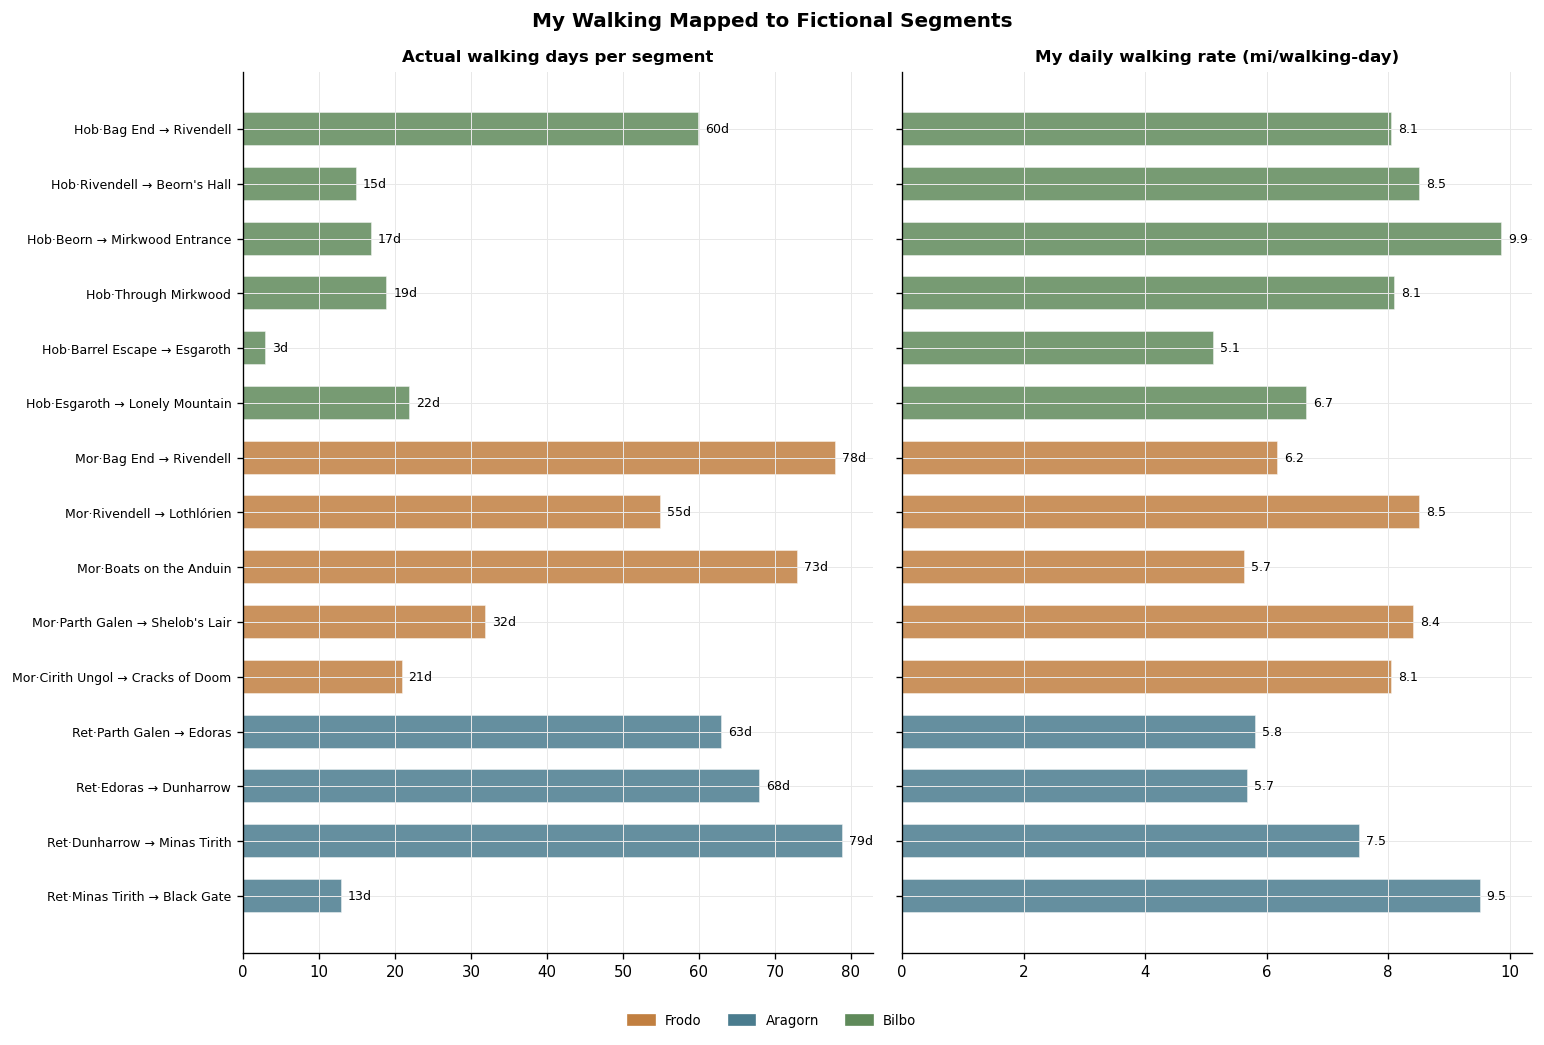

In [11]:
# ── Figure: actual walking days per fictional segment ─────────────────────────
move_sorted = move.sort_values(["journey","fi_mi_start"])
n = len(move_sorted)

fig, axes = plt.subplots(1, 2, figsize=(13, max(5, n * 0.46 + 1.5)))
fig.suptitle("My Walking Mapped to Fictional Segments",
             fontsize=12, fontweight="bold")

ys = np.arange(n)
jcolors = [C[r["journey"]] for _, r in move_sorted.iterrows()]

for ax, col, title, fmt_fn in [
    (axes[0], "w_days",
     "Actual walking days per segment",
     lambda r: f"{int(r.w_days)}d"),
    (axes[1], "w_rate",
     "My daily walking rate (mi/walking-day)",
     lambda r: f"{r.w_rate:.1f}"),
]:
    vals = move_sorted[col].values
    ax.barh(ys, vals, color=jcolors, height=0.62, alpha=0.85, edgecolor="white")
    for y, (v, row) in enumerate(zip(vals, move_sorted.itertuples())):
        ax.text(v + max(vals)*0.01, y, fmt_fn(row), va="center", fontsize=7.5)
    ax.set_yticks(ys)
    if ax == axes[0]:
        ax.set_yticklabels(
            [f"{r['journey'][:3]}·{r['segment']}" for _, r in move_sorted.iterrows()],
            fontsize=7.5)
    else:
        ax.set_yticklabels([])
    ax.set_title(title, fontsize=10, fontweight="bold")
    ax.invert_yaxis()
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

handles = [mpatches.Patch(color=C[j], label=LABEL[j].split("—")[0].strip())
           for j in JORDER]
fig.legend(handles=handles, loc="lower center", ncol=3,
           fontsize=8, frameon=False, bbox_to_anchor=(0.5, -0.04))
fig.tight_layout()
plt.show()

**Walking through fictional segments.** My actual walking rate (mi/walking-day) is broadly similar across segments within each journey, which reflects consistent daily activity rather than the fictional travel mode. The variation in walking days per segment largely mirrors the fictional mileage of the segment — longer segments took more walking days, with my rate being roughly the same throughout. 

The contrast with fictional travel rates is the key story: a segment that takes 5 ME days on horseback (e.g., Edoras → Dunharrow, 382 fi-mi) required 67 of my actual walking days to cover the same fictional distance.

## 9. Daily Walking Behaviour

In [12]:
# ── Per-journey distribution stats ────────────────────────────────────────────
dist_stats = []
for jid in JORDER:
    d = walk[walk["journey_id"] == jid]["distance_miles"]
    dist_stats.append(dict(
        journey=LABEL[jid].split("—")[0].strip(),
        n=len(d), median=round(d.median(),2), mean=round(d.mean(),2),
        std=round(d.std(),2), iqr=round(d.quantile(.75)-d.quantile(.25),2),
        p10=round(d.quantile(.10),2), p90=round(d.quantile(.90),2),
        pct_ge2=round((d>=2).mean()*100,1),
        pct_ge5=round((d>=5).mean()*100,1),
        pct_ge10=round((d>=10).mean()*100,1),
    ))
display(pd.DataFrame(dist_stats).set_index("journey"))

,n,median,mean,std,iqr,p10,p90,pct_ge2,pct_ge5,pct_ge10
journey,,,,,,,,,,
Frodo,261,7.12,6.98,3.37,4.63,2.17,11.16,90.8,72.4,17.6
Aragorn,225,6.49,6.64,2.93,3.71,3.06,10.04,96.4,70.2,10.7
Bilbo,142,7.93,8.09,3.09,5.00,4.01,11.87,99.3,81.7,31.7


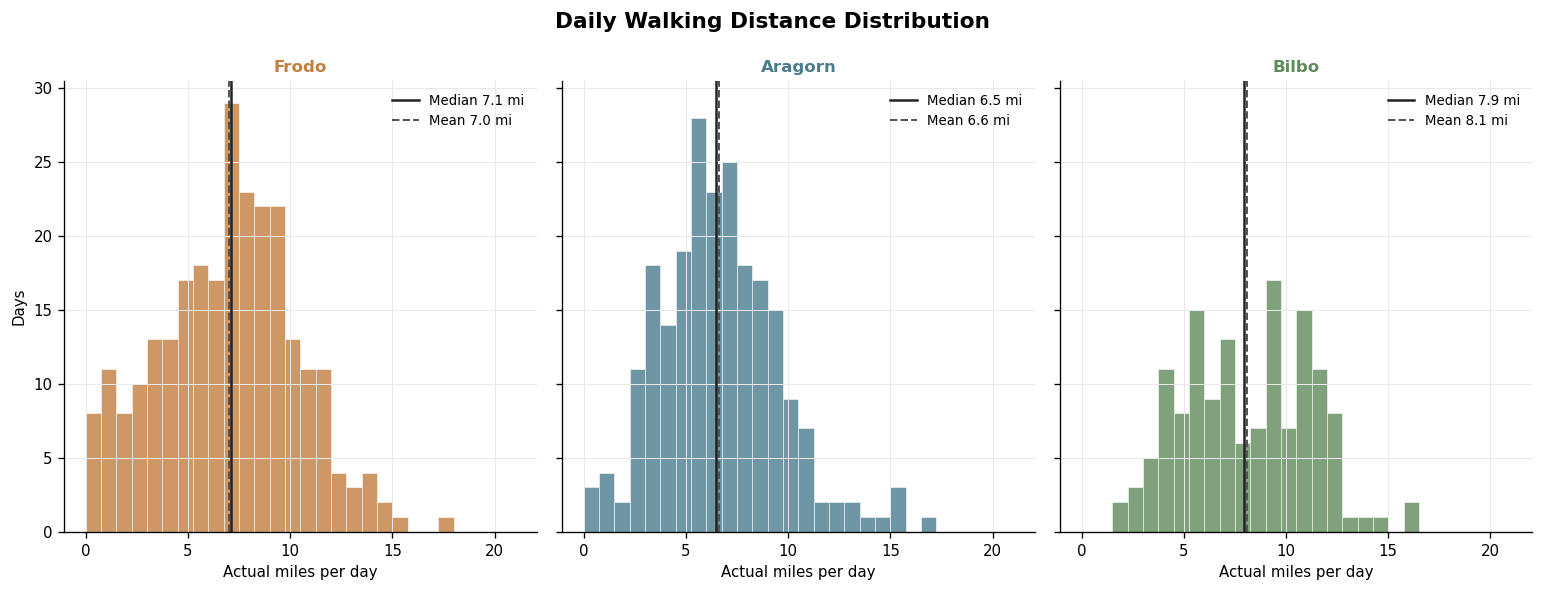

In [13]:
# ── Distribution figure ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 5), sharey=True)
fig.suptitle("Daily Walking Distance Distribution",
             fontsize=13, fontweight="bold")

bins = np.arange(0, 21.5, 0.75)

for ax, jid in zip(axes, JORDER):
    color = C[jid]
    d = walk[walk["journey_id"] == jid]["distance_miles"]
    med = d.median()
    mn  = d.mean()

    ax.hist(d, bins=bins, color=color, alpha=0.80, edgecolor="white", linewidth=0.4)
    ax.axvline(med, color="#222222", linewidth=1.5, label=f"Median {med:.1f} mi")
    ax.axvline(mn,  color="#555555", linewidth=1.2, linestyle="--",
               label=f"Mean {mn:.1f} mi")

    ax.set_title(LABEL[jid].split("—")[0].strip(),
                 fontsize=10, fontweight="bold", color=color)
    ax.set_xlabel("Actual miles per day", fontsize=9)
    if ax == axes[0]:
        ax.set_ylabel("Days", fontsize=9)

    ax.legend(fontsize=8, loc="upper right")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.tight_layout()
plt.show()

**Daily distance observations.** The three distributions are similar in shape — roughly unimodal, centred between 6 and 9 miles, with a right tail. Bilbo's journey has the highest median (7.93 mi) and the highest share of days at ≥10 mi (31.7%), which may reflect a period of increased average activity rather than a deliberate change in approach. Frodo's journey has the most days under 2 miles (9.2%), consistent with the longer journey spanning more varied calendar conditions. These are purely observational statements; the data do not reveal causes.

## 10. Key Findings

The following findings are drawn directly from calculated values above.

In [14]:
# Print verified numbers for the findings narrative
fr = js[js.journey=="Mordor"].iloc[0]
ar = js[js.journey=="Return"].iloc[0]
bi = js[js.journey=="Hobbit"].iloc[0]

# Boat rate vs walking rate for Mordor
boat_row  = segs[(segs.journey=="Mordor") & (segs.segment=="Boats on the Anduin")].iloc[0]
walk_segs_mordor = segs[(segs.journey=="Mordor") & (segs.fi_mi>0) & (segs.travel=="walking")]
avg_walk_rate = walk_segs_mordor["fi_rate"].mean()

# Rivendell rest
riv_rest = segs[(segs.journey=="Mordor") & (segs.segment=="Rivendell Rest")].iloc[0]
loth_rest = segs[(segs.journey=="Mordor") & (segs.segment=="Lothlórien Rest")].iloc[0]

# Bilbo rests
bi_rests = segs[(segs.journey=="Hobbit") & (segs.fi_mi==0)]
bi_rest_days_total = bi_rests["me_days"].sum()

# Aragorn horseback
ar_horse_segs = segs[(segs.journey=="Return") & (segs.travel=="horseback")]

# Pony leg (Bilbo)
pony_seg = segs[(segs.journey=="Hobbit") & (segs.segment=="Beorn → Mirkwood Entrance")].iloc[0]

print("Key numbers for findings:")
print(f"  Return time ratio: {ar.time_ratio}×")
print(f"  Frodo time ratio: {fr.time_ratio}×")
print(f"  Bilbo time ratio: {bi.time_ratio}×")
print(f"  Boat rate (Anduin): {boat_row.fi_rate} fi-mi/ME-day")
print(f"  Avg Mordor walking rate: {avg_walk_rate:.2f} fi-mi/ME-day")
print(f"  Rivendell rest ME days: {riv_rest.me_days}")
print(f"  Lothlórien rest ME days: {loth_rest.me_days}")
print(f"  Frodo stationary ME days: {fr.me_rest_days} ({fr.me_rest_days/fr.me_elapsed*100:.0f}% of journey)")
print(f"  Bilbo total rest ME days: {bi_rest_days_total} ({bi_rest_days_total/bi.me_elapsed*100:.0f}% of journey)")
print(f"  Aragorn horseback rates: {ar_horse_segs['fi_rate'].tolist()}")
print(f"  Pony leg (Beorn→Mirkwood): {pony_seg.fi_rate} fi-mi/ME-day, {pony_seg.me_days} ME days")

Key numbers for findings:
  Return time ratio: 7.5×
  Frodo time ratio: 1.55×
  Bilbo time ratio: 0.67×
  Boat rate (Anduin): 37.73 fi-mi/ME-day
  Avg Mordor walking rate: 16.82 fi-mi/ME-day
  Rivendell rest ME days: 65
  Lothlórien rest ME days: 28
  Frodo stationary ME days: 95 (51% of journey)
  Bilbo total rest ME days: 72 (34% of journey)
  Aragorn horseback rates: [52.86, 77.4]
  Pony leg (Beorn→Mirkwood): 41.75 fi-mi/ME-day, 4 ME days


### Findings

Each finding cites the numerical evidence computed in the cell above.

---

**1. The three journeys diverge dramatically in how much ME time they consume relative to real-world time.**

Aragorn's Return has a real/ME time ratio of 7.5×: 225 actual calendar days mapped onto just 30 ME days. Frodo's ratio is 1.55×. Bilbo's is 0.67× — his 212 ME days span only 142 actual calendar days, making him the only journey where my real walking outpaced the fictional timeline. The range (0.67× to 7.5×) shows that the same fictional mileage bracket is a very different temporal experience depending on which clock is read.

---

**2. Frodo's fictional mileage is stationary for more than half its duration.**

Of Frodo's 185 ME days, 95 are stationary (51%): 65 at Rivendell (mi=487) and 28 at Lothlórien (mi=952). These are the two largest flat plateaus in the dataset. In my actual walking, I crossed both mileage marks during uninterrupted forward progress — there is no corresponding real-world pause.

---

**3. The Anduin boat segment is the fastest fictional travel mode in Frodo's route, at 2.2× the mean walking rate.**

The Boats on the Anduin covers 415 fictional miles in 11 ME days (37.7 fi-mi/day). The mean fictional travel rate across Frodo's four walking segments is 16.8 fi-mi/day. The boat leg is approximately 2.2× faster. The Anduin segment produces a visibly steeper slope in the cumulative ME-time chart — a shape that has no equivalent in my walking data, which progresses at a much slower and more variable daily rate.

---

**4. Aragorn's horseback segments are the highest fictional travel rates in the dataset.**

Parth Galen → Edoras runs at 52.9 fi-mi/ME-day; Edoras → Dunharrow at 77.4 fi-mi/ME-day; Dunharrow → Minas Tirith (Paths of the Dead + ships, annotated "mixed") at 74.1 fi-mi/ME-day. My actual walking rate during the corresponding mileage intervals was 5.7–7.5 mi/walking-day. The fictional characters covered in one ME day what I walked over roughly 9–14 real days.

---

**5. Bilbo's pony leg (Beorn → Mirkwood) is the fastest non-Return segment, at 41.8 fi-mi/day.**

Four ME days, 167 fictional miles. The preceding Mirkwood walking segment runs at 5.1 fi-mi/day — the pony leg is 8× faster in fictional terms. My actual walking rate across those same fictional miles was 9.9 mi/walking-day, within the range of my daily walking rates elsewhere in the journey.

---

**6. Bilbo spends 34% of his fictional timeline stationary across three separate interruptions.**

Rivendell rest (28 ME days), Wood-elves captivity (27 ME days), and Lake-town rest (17 ME days) total 72 stationary ME days out of 212 (34%). Unlike Frodo's two rests, Bilbo's stationary periods are distributed across the middle of the journey, creating a more fragmented fictional mileage curve.

---

**7. My actual daily walking distribution is broadly similar across all three journeys.**

Medians: Frodo 7.1 mi, Aragorn 6.5 mi, Bilbo 7.9 mi. Standard deviations: 3.4, 2.9, 3.1. All three distributions are roughly unimodal with right tails. The journeys span two and a half calendar years, different seasons, and vastly different fictional contexts — yet the underlying walking behaviour shows no dramatic shift between them.


## 11. Limitations & Interpretation

**Fictional mileage calibration.** Distances in `me_time.csv` are calibrated narrative figures, not map measurements. Different scholars or editions give different distances for the same Tolkien journeys. The segment rates computed here are entirely dependent on this calibration.

**Narrative travel mode.** Travel mode annotations (walking, horseback, boat, etc.) are interpretations drawn from `chronology.json` and source text. They are editorial classifications, not measured data. The user always walked; the fictional characters did not.

**Segment boundaries.** The me_time plateau analysis reveals unambiguous flat periods for rest/captivity. However, within movement segments, the travel mode and narrative context are inferred rather than directly measured. A segment marked "walking" may include short boat crossings or brief rests not large enough to appear as plateaus in the ordinal data.

**Actual walking to fictional segment mapping.** Walking days are assigned to fictional segments via cumulative mileage crossings. This is a clean mapping for the majority of data, but days that straddle a segment boundary (cumulative mileage crosses the threshold mid-day) are assigned entirely to the upper segment. No fractional day splitting is performed.

**One-person dataset.** All walking statistics describe a single individual over a defined period. No population claims, causal inference, or generalisability is warranted.

**Google Fit measurement.** Step data was aggregated from Google Fit, with a conversion factor of approximately 1 step ≈ 0.0005 miles (2,000 steps/mile). Known rounding introduces a small error (±3 steps/day). Two outlier low-step days were verified as plausible in prior analysis and are not removed.

**ME calendar.** The Shire calendar has 12 months of 30 days plus intercalary days, and ordinal arithmetic treats all days as equivalent. This is a reasonable approximation for duration analysis but does not reflect any real astronomical or cultural meaning of the Tolkien dates.